#**Projeto Chronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# 04 — Desafio 1: Previsão de Volume (SARIMAX) | Projeto Cronos

**Premissas assumidas:**
-  **Abordagem Bottom-Up**: P2 (Alta) e P3 (Média) têm comportamento diferente — em vez de modelar a soma direto, treinamos **um modelo para cada prioridade** e somamos as previsões no final. A ideia: cada modelo aprende a curva específica da sua prioridade, em vez de uma curva combinada que borra os dois padrões.
- **Métricas robustas** (MedAE/MdAPE, mediana) ao lado das médias, para não deixar um único dia extremo distorcer a leitura de qual modelo é melhor.
- **Teste de parcimônia**: `dow_sin`/`dow_cos` estatisticamente irrelevantes (p=0,81 e p=0,98) — testamos remover.
- **Reteste da escala (bruta vs. `log1p`) nos 3 folds**, não só no fold contaminado pelo salto — com correção de viés de Duan na reversão do log (`np.expm1` sozinho subestima sistematicamente).
- **Diagnóstico formal de resíduos** (Ljung-Box, Jarque-Bera, Breusch-Pagan) e **intervalo de previsão por bootstrap dos resíduos**, como alternativa ao IC gaussiano — a curtose de 27,69 encontrada antes indica que a suposição de normalidade não se sustenta.

**Decisão de arquitetura**: as séries diárias de P2 e P3 (elegíveis para KPI) **não vêm de `gold_volume_diario`** — essa tabela só tem a soma de P2+P3, não separadas por prioridade.


Observação: destrinchamos o que é ruído, sazonalidade e padrão nas séries de P2 e P3, separadamente — com decomposição STL, ACF/PACF e a investigação de saltos anômalos.

**Desenho da validação:**
| Fold | Treino | Teste |
|---|---|---|
| 1 | semanas 01–30 | semanas 31–37 |
| 2 | semanas 01–37 | semanas 38–44 |
| 3 | semanas 01–44 | semanas 45–51 |


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [2]:
import sys
sys.path.append('/content/drive/MyDrive/cronos_project')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    setup_logging, PROJECT_PATHS, load_parquet_layer, generate_expanding_folds,
    calcular_metricas_serie, compute_all_baselines, baseline_rolling_mean,
    SPECS_SARIMAX_PADRAO, rodar_variante_sarimax, construir_exogenas_futuras,
    checar_faixa_kpi, FAIXAS_VOLUME_ANUAL_P2, FAIXAS_VOLUME_ANUAL_P3,
    detectar_saltos_anomalos, bootstrap_prediction_interval,
    log1p_bias_corrected_forecast, diagnostico_residuos, salvar_artefato,
)

logger = setup_logging('sarimax_bottomup')


In [3]:
!pip install pmdarima -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 11.3 MB/s eta 0:00:00


In [4]:
import pmdarima as pm
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


## Decisão de negócio — usar apenas o que entra em KPI

A decisão do grupo é **modelar exclusivamente a série elegível** — é o que a Locaweb monitora de fato e o que aparece nas metas anuais oficiais (Dicionário de Dados v2), ou seja, é o recorte que reflete a preocupação real do negócio. A série bruta continua sendo mostrada logo abaixo, como evidência que sustenta essa decisão, mas nunca alimenta nenhum modelo deste notebook.

In [5]:
USAR_APENAS_ELEGIVEL_KPI = True  # decisão de negócio: só o que entra em KPI — ver justificativa acima
MODO_DADOS = 'elegível para KPI'
logger.info('Modo de dados deste notebook: %s (decisão de negócio, não um parâmetro a testar).', MODO_DADOS)


2026-08-30 16:36:53 | INFO     | sarimax_bottomup | Modo de dados deste notebook: elegível para KPI (decisão de negócio, não um parâmetro a testar).


INFO:sarimax_bottomup:Modo de dados deste notebook: elegível para KPI (decisão de negócio, não um parâmetro a testar).


---
## PARTE 0 — Ruído, sazonalidade e padrão

A decomposição STL abaixo separa esses três componentes de forma visual e numérica — feita **separadamente para P2 e P3**, porque a hipótese de trabalho (a razão de fazer bottom-up) é que esses componentes têm peso diferente nas duas séries.


### 0.1 Carga das séries P2 e P3 — elegível e bruta, sempre as duas

2026-08-30 16:36:55 | INFO     | sarimax_bottomup | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax_bottomup:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_chamados_risco.parquet: 121811 linhas x 35 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


2026-08-30 16:36:55 | INFO     | sarimax_bottomup | Série P2 elegível: média 14.1/dia, total 5159 no ano.


INFO:sarimax_bottomup:Série P2 elegível: média 14.1/dia, total 5159 no ano.


2026-08-30 16:36:55 | INFO     | sarimax_bottomup | Série P3 elegível: média 54.8/dia, total 19997 no ano.


...

INFO:sarimax_bottomup:Série P3 bruta: média 113.0/dia, total 41260 no ano.


2026-08-30 16:36:55 | INFO     | sarimax_bottomup | Séries ativas para modelagem neste notebook: elegível para KPI.


INFO:sarimax_bottomup:Séries ativas para modelagem neste notebook: elegível para KPI.


2026-08-30 16:36:56 | INFO     | sarimax_bottomup | Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 21 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


INFO:sarimax_bottomup:Lido de /content/drive/MyDrive/cronos_project/data/gold/gold_volume_diario.parquet: 365 linhas x 21 colunas (2 colunas de metadado: ['_ingested_at', '_source_layer']).


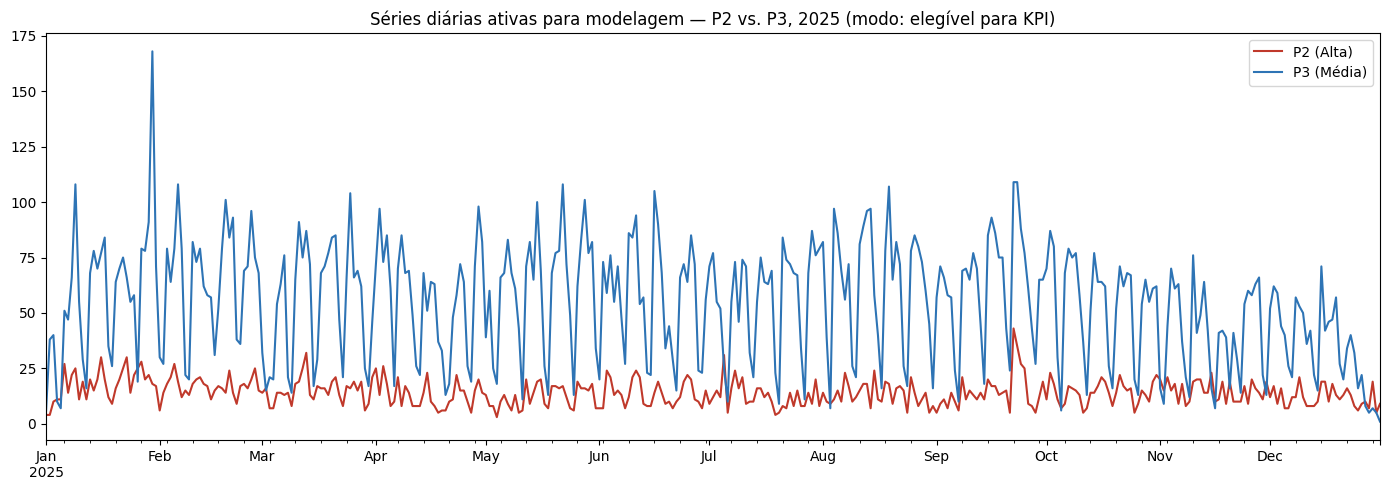

In [6]:
gold_risco_path = PROJECT_PATHS.gold / 'gold_chamados_risco.parquet'
df_risco = load_parquet_layer(gold_risco_path, logger=logger)
df_risco['Aberto'] = pd.to_datetime(df_risco['Aberto'])
df_risco['data'] = df_risco['Aberto'].dt.date

df_elegivel = df_risco[df_risco['Entrou para KPI?'] == 'SIM'].copy()

indice_completo = pd.date_range('2025-01-01', '2025-12-31', freq='D')

def carregar_serie_diaria(df_fonte, prioridade):
    serie = df_fonte[df_fonte['Prioridade'] == prioridade].groupby('data').size()
    serie.index = pd.to_datetime(serie.index)
    return serie.reindex(indice_completo, fill_value=0)

serie_p2_elegivel = carregar_serie_diaria(df_elegivel, '2 - Alta')
serie_p3_elegivel = carregar_serie_diaria(df_elegivel, '3 - Média')
serie_p2_bruta = carregar_serie_diaria(df_risco, '2 - Alta')
serie_p3_bruta = carregar_serie_diaria(df_risco, '3 - Média')

logger.info('Série P2 elegível: média %.1f/dia, total %d no ano.', serie_p2_elegivel.mean(), serie_p2_elegivel.sum())
logger.info('Série P3 elegível: média %.1f/dia, total %d no ano.', serie_p3_elegivel.mean(), serie_p3_elegivel.sum())
logger.info('Série P2 bruta: média %.1f/dia, total %d no ano.', serie_p2_bruta.mean(), serie_p2_bruta.sum())
logger.info('Série P3 bruta: média %.1f/dia, total %d no ano.', serie_p3_bruta.mean(), serie_p3_bruta.sum())

serie_p2 = serie_p2_elegivel if USAR_APENAS_ELEGIVEL_KPI else serie_p2_bruta
serie_p3 = serie_p3_elegivel if USAR_APENAS_ELEGIVEL_KPI else serie_p3_bruta
logger.info('Séries ativas para modelagem neste notebook: %s.', MODO_DADOS)

gold_volume_path = PROJECT_PATHS.gold / 'gold_volume_diario.parquet'
gold_volume_ref = load_parquet_layer(gold_volume_path, logger=logger)
gold_volume_ref['data'] = pd.to_datetime(gold_volume_ref['data'])
exogenas = gold_volume_ref.set_index('data')[['fim_de_semana', 'feriado', 'vespera_feriado', 'dia_seguinte_feriado', 'dow_sin', 'dow_cos']]
exogenas = exogenas.reindex(indice_completo)

fig, ax = plt.subplots(figsize=(14, 5))
serie_p2.plot(ax=ax, label='P2 (Alta)', color='#c0392b')
serie_p3.plot(ax=ax, label='P3 (Média)', color='#2E74B5')
ax.legend()
ax.set_title(f'Séries diárias ativas para modelagem — P2 vs. P3, 2025 (modo: {MODO_DADOS})')
plt.tight_layout()
plt.show()


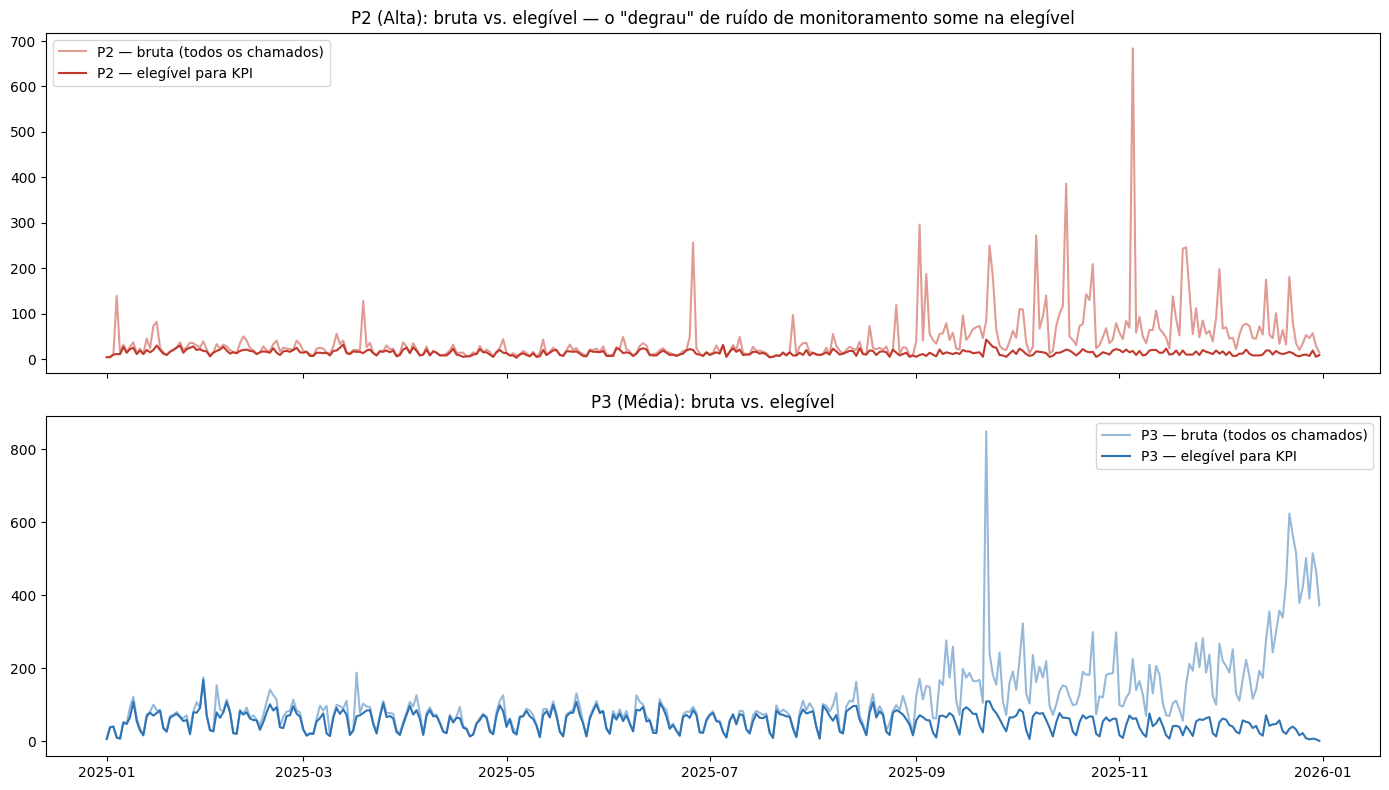

2026-08-30 16:37:00 | INFO     | sarimax_bottomup | P2: a série bruta tem 3.0x mais chamados que a elegível no ano.


INFO:sarimax_bottomup:P2: a série bruta tem 3.0x mais chamados que a elegível no ano.


2026-08-30 16:37:00 | INFO     | sarimax_bottomup | P3: a série bruta tem 2.1x mais chamados que a elegível no ano.


INFO:sarimax_bottomup:P3: a série bruta tem 2.1x mais chamados que a elegível no ano.


2026-08-30 16:37:00 | INFO     | sarimax_bottomup | Decisão de negócio confirmada: modelando apenas a série elegível para KPI.


INFO:sarimax_bottomup:Decisão de negócio confirmada: modelando apenas a série elegível para KPI.


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(serie_p2_bruta.index, serie_p2_bruta.values, label='P2 — bruta (todos os chamados)', color='#c0392b', alpha=0.5)
axes[0].plot(serie_p2_elegivel.index, serie_p2_elegivel.values, label='P2 — elegível para KPI', color='#c0392b')
axes[0].legend()
axes[0].set_title('P2 (Alta): bruta vs. elegível — o "degrau" de ruído de monitoramento some na elegível')

axes[1].plot(serie_p3_bruta.index, serie_p3_bruta.values, label='P3 — bruta (todos os chamados)', color='#2E74B5', alpha=0.5)
axes[1].plot(serie_p3_elegivel.index, serie_p3_elegivel.values, label='P3 — elegível para KPI', color='#2E74B5')
axes[1].legend()
axes[1].set_title('P3 (Média): bruta vs. elegível')

plt.tight_layout()
plt.show()

razao_p2 = serie_p2_bruta.sum() / serie_p2_elegivel.sum()
razao_p3 = serie_p3_bruta.sum() / serie_p3_elegivel.sum()
logger.info('P2: a série bruta tem %.1fx mais chamados que a elegível no ano.', razao_p2)
logger.info('P3: a série bruta tem %.1fx mais chamados que a elegível no ano.', razao_p3)
logger.info('Decisão de negócio confirmada: modelando apenas a série %s.', MODO_DADOS)


### 0.2 Decomposição STL — separando tendência, sazonalidade e resíduo

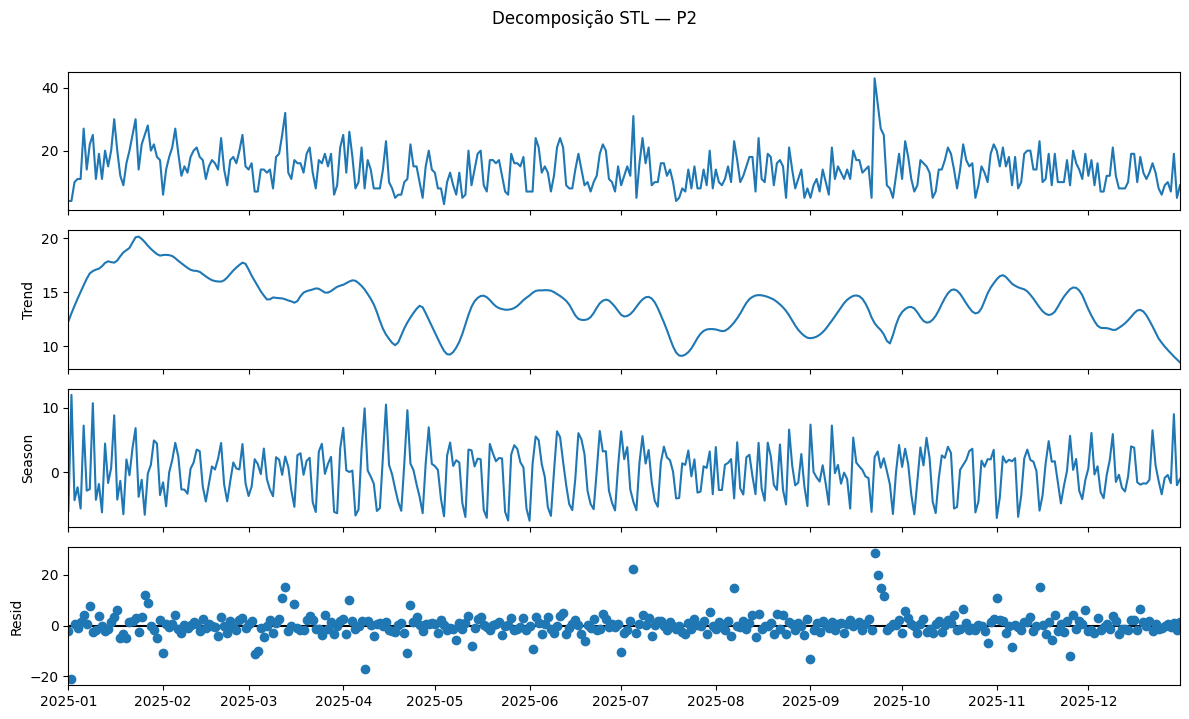

2026-08-30 16:37:01 | INFO     | sarimax_bottomup | P2: força da sazonalidade=0.332 | força da tendência=0.231 (0=ausente, 1=domina)


INFO:sarimax_bottomup:P2: força da sazonalidade=0.332 | força da tendência=0.231 (0=ausente, 1=domina)


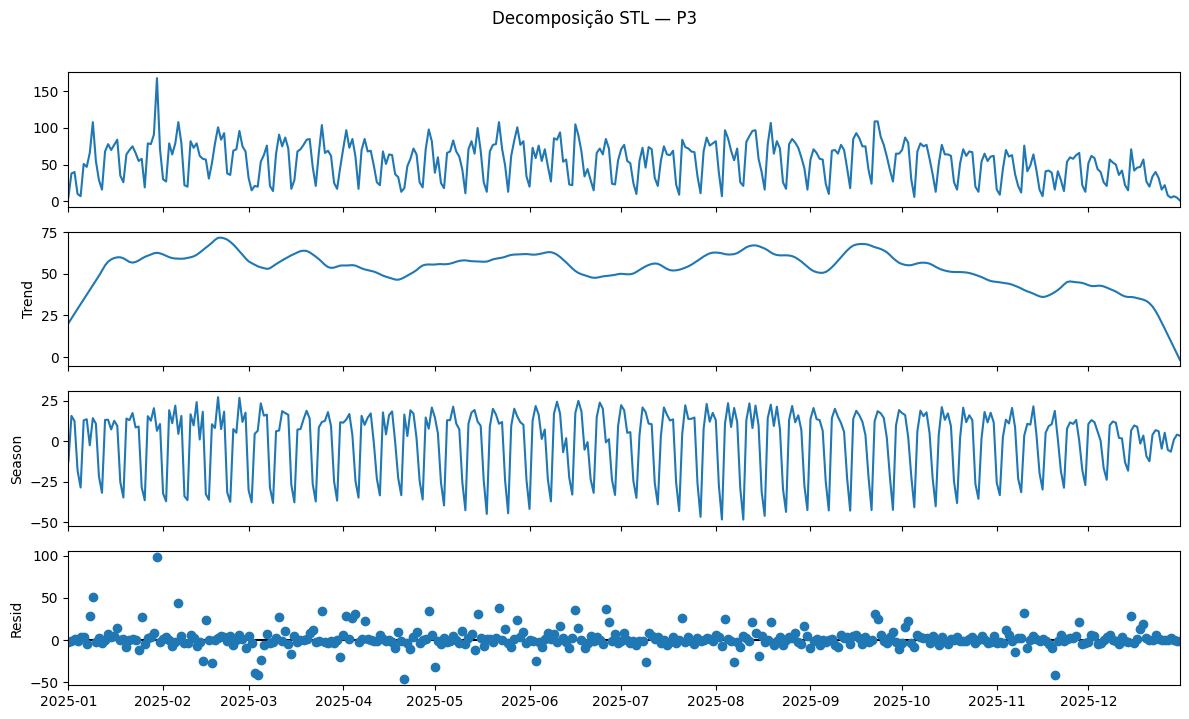

2026-08-30 16:37:03 | INFO     | sarimax_bottomup | P3: força da sazonalidade=0.737 | força da tendência=0.461 (0=ausente, 1=domina)


INFO:sarimax_bottomup:P3: força da sazonalidade=0.737 | força da tendência=0.461 (0=ausente, 1=domina)


In [8]:
SERIES = {'P2': serie_p2, 'P3': serie_p3}
resultados_stl = {}

for nome, serie in SERIES.items():
    stl = STL(serie, period=7, robust=True)
    resultado = stl.fit()
    resultados_stl[nome] = resultado

    fig = resultado.plot()
    fig.set_size_inches(12, 7)
    fig.suptitle(f'Decomposição STL — {nome}', y=1.02)
    plt.tight_layout()
    plt.show()

    forca_sazonalidade = max(0, 1 - resultado.resid.var() / (resultado.seasonal + resultado.resid).var())
    forca_tendencia = max(0, 1 - resultado.resid.var() / (resultado.trend + resultado.resid).var())
    logger.info('%s: força da sazonalidade=%.3f | força da tendência=%.3f (0=ausente, 1=domina)', nome, forca_sazonalidade, forca_tendencia)


### 0.3 ACF/PACF — o padrão de autocorrelação de cada série

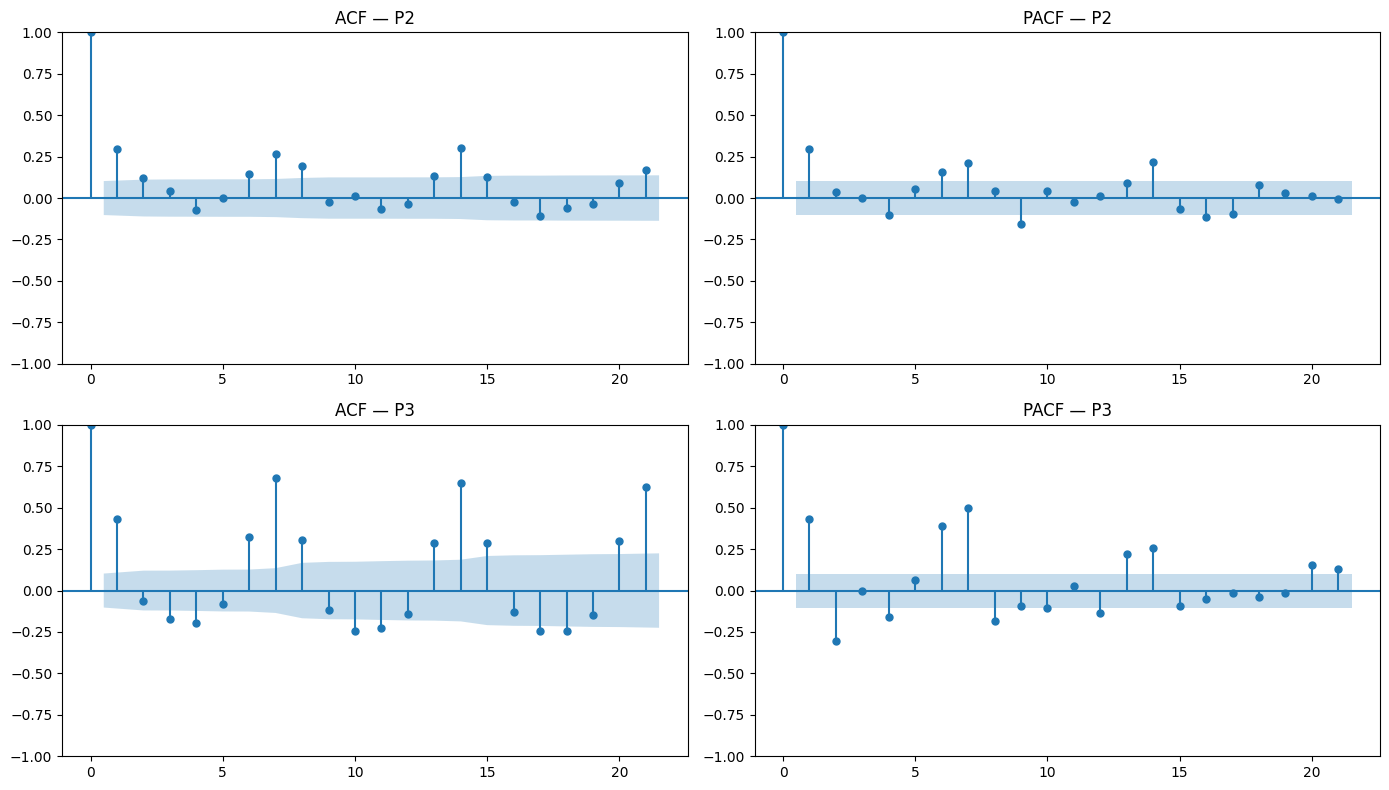

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, (nome, serie) in enumerate(SERIES.items()):
    plot_acf(serie, lags=21, ax=axes[i, 0], title=f'ACF — {nome}')
    plot_pacf(serie, lags=21, ax=axes[i, 1], title=f'PACF — {nome}')
plt.tight_layout()
plt.show()


### 0.4 Investigação de saltos anômalos (ruído) — separada por prioridade

Checagem se os mesmos dias aparecem como anômalos nas duas prioridades, ou se é um fenômeno específico de uma delas.

In [10]:
saltos_por_serie = {}
for nome, serie in SERIES.items():
    saltos = detectar_saltos_anomalos(serie, limiar_desvios=3.0)
    saltos_por_serie[nome] = saltos
    logger.info('%s: %d saltos anômalos detectados.', nome, len(saltos))
    if len(saltos):
        display(saltos)


2026-08-30 16:37:05 | INFO     | sarimax_bottomup | P2: 2 saltos anômalos detectados.


INFO:sarimax_bottomup:P2: 2 saltos anômalos detectados.


,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-07-06,5,-26.0,-3.7
1,2025-09-22,43,38.0,5.4


2026-08-30 16:37:05 | INFO     | sarimax_bottomup | P3: 3 saltos anômalos detectados.


INFO:sarimax_bottomup:P3: 3 saltos anômalos detectados.


,data,valor,variacao_dia_anterior,desvios_padrao
0,2025-01-31,71,-97.0,-3.45
1,2025-08-04,97,90.0,3.20
2,2025-09-22,109,85.0,3.02


---
## PARTE 1 — Folds walk-forward

In [11]:
folds = generate_expanding_folds(start_date='2025-01-01', min_train_weeks=30, test_weeks=7, n_folds=3)
for f in folds:
    logger.info(
        "Fold %d: treino %s a %s (%d dias) | teste %s a %s (%d dias)",
        f['fold'], f['train_start'].date(), f['train_end'].date(),
        (f['train_end'] - f['train_start']).days + 1,
        f['test_start'].date(), f['test_end'].date(),
        (f['test_end'] - f['test_start']).days + 1,
    )

2026-08-30 16:37:05 | INFO     | sarimax_bottomup | Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


INFO:sarimax_bottomup:Fold 1: treino 2025-01-01 a 2025-07-29 (210 dias) | teste 2025-07-30 a 2025-09-16 (49 dias)


2026-08-30 16:37:05 | INFO     | sarimax_bottomup | Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


INFO:sarimax_bottomup:Fold 2: treino 2025-01-01 a 2025-09-16 (259 dias) | teste 2025-09-17 a 2025-11-04 (49 dias)


2026-08-30 16:37:05 | INFO     | sarimax_bottomup | Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


INFO:sarimax_bottomup:Fold 3: treino 2025-01-01 a 2025-11-04 (308 dias) | teste 2025-11-05 a 2025-12-23 (49 dias)


---
## PARTE 2 — Modelagem Bottom-Up: competição de variantes, por prioridade

Em vez de duplicar cada célula para P2 e para P3, o loop abaixo roda a **mesma competição de especificações** (`d=1`, `max_p=3`/`max_q=3`, BIC) para cada série, guardando os resultados num dicionário indexado por prioridade.

In [12]:
nomes_variantes = ['sarima_classico', 'arimax_fourier', 'sarimax_hibrido']

resultados_por_serie = {}
for nome_serie, serie in SERIES.items():
    logger.info('========== Série %s ==========', nome_serie)
    resultados_fold = []
    modelos_por_fold = {}

    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        previsoes = compute_all_baselines(serie_treino, len(serie_teste))

        modelos_por_fold[f['fold']] = {}
        for nome_variante in nomes_variantes:
            info = rodar_variante_sarimax(nome_variante, SPECS_SARIMAX_PADRAO[nome_variante], serie_treino, serie_teste, exog_treino, exog_teste)
            previsoes[nome_variante] = info['previsao']
            modelos_por_fold[f['fold']][nome_variante] = info
            assert info['ordem'][1] == 1, f'{nome_serie} fold {f["fold"]} [{nome_variante}]: d deveria ser 1!'

        for nome_modelo, y_previsto in previsoes.items():
            m = calcular_metricas_serie(serie_teste.values, y_previsto)
            resultados_fold.append({'serie': nome_serie, 'fold': f['fold'], 'modelo': nome_modelo, **{f'{k}_horizonte': v for k, v in m.items()}})

    resultados_por_serie[nome_serie] = {'resultados_fold': pd.DataFrame(resultados_fold), 'modelos_por_fold': modelos_por_fold}
    logger.info('%s: competição concluída nos 3 folds.', nome_serie)


2026-08-30 16:37:05 | INFO     | sarimax_bottomup | ========== Série P2 ==========


INFO:sarimax_bottomup:========== Série P2 ==========


2026-08-30 16:44:23 | INFO     | sarimax_bottomup | P2: competição concluída nos 3 folds.


INFO:sarimax_bottomup:P2: competição concluída nos 3 folds.


2026-08-30 16:44:23 | INFO     | sarimax_bottomup | ========== Série P3 ==========


INFO:sarimax_bottomup:========== Série P3 ==========


2026-08-30 16:52:58 | INFO     | sarimax_bottomup | P3: competição concluída nos 3 folds.


INFO:sarimax_bottomup:P3: competição concluída nos 3 folds.


---
## PARTE 3 — Comparação consolidada, por prioridade

In [13]:
melhor_variante_por_serie = {}

for nome_serie in SERIES:
    df_resultados = resultados_por_serie[nome_serie]['resultados_fold']
    resumo = df_resultados.groupby('modelo')[['MAE_horizonte', 'MedAE_horizonte', 'RMSE_horizonte']].mean().round(2).sort_values('MAE_horizonte')
    melhor = resumo.loc[resumo.index.isin(nomes_variantes), 'MAE_horizonte'].idxmin()
    melhor_variante_por_serie[nome_serie] = melhor
    logger.info('%s: melhor variante = %s', nome_serie, melhor)
    print(f'--- {nome_serie} ---')
    display(resumo)


2026-08-30 16:52:58 | INFO     | sarimax_bottomup | P2: melhor variante = arimax_fourier


INFO:sarimax_bottomup:P2: melhor variante = arimax_fourier


--- P2 ---


,MAE_horizonte,MedAE_horizonte,RMSE_horizonte
modelo,,,
arimax_fourier,4.32,3.24,5.84
sarima_classico,4.34,3.71,5.61
sarimax_hibrido,4.47,3.43,5.89
arima_puro,4.56,3.89,5.74
rolling_mean_7d,4.73,4.33,6.14
naive,4.87,4.00,6.11
seasonal_naive,5.20,4.00,6.47


2026-08-30 16:52:58 | INFO     | sarimax_bottomup | P3: melhor variante = sarima_classico


INFO:sarimax_bottomup:P3: melhor variante = sarima_classico


--- P3 ---


,MAE_horizonte,MedAE_horizonte,RMSE_horizonte
modelo,,,
sarima_classico,11.87,9.71,14.69
seasonal_naive,11.90,9.33,14.83
arimax_fourier,12.07,11.23,14.74
sarimax_hibrido,13.11,12.71,15.90
rolling_mean_7d,18.92,15.29,23.63
arima_puro,31.63,25.67,38.25
naive,31.63,25.67,38.25


---
## PARTE 4 — Teste de parcimônia, por prioridade

Comparar a especificação vencedora completa contra a versão sem os termos de Fourier (`dow_sin`/`dow_cos`).

In [14]:
especificacao_final_por_serie = {}

for nome_serie, serie in SERIES.items():
    melhor = melhor_variante_por_serie[nome_serie]
    if melhor != 'arimax_fourier':
        # o teste de parcimônia (remover Fourier) só se aplica quando a variante vencedora usa Fourier
        especificacao_final_por_serie[nome_serie] = melhor
        logger.info('%s: melhor variante (%s) não usa Fourier — parcimônia não se aplica, mantendo como está.', nome_serie, melhor)
        continue

    resultados_parcimonia = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        info_completo = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']]['arimax_fourier']
        info_parcimonioso = rodar_variante_sarimax('arimax_fourier_parcimonioso', SPECS_SARIMAX_PADRAO['arimax_fourier_parcimonioso'], serie_treino, serie_teste, exog_treino, exog_teste)

        resultados_parcimonia.append({
            'fold': f['fold'],
            'BIC_completo': info_completo['bic'], 'BIC_parcimonioso': info_parcimonioso['bic'],
            'MAE_completo': calcular_metricas_serie(serie_teste.values, info_completo['previsao'])['MAE'],
            'MAE_parcimonioso': calcular_metricas_serie(serie_teste.values, info_parcimonioso['previsao'])['MAE'],
        })

    df_parcimonia = pd.DataFrame(resultados_parcimonia)
    df_parcimonia['BIC_favorece_parcimonioso'] = df_parcimonia['BIC_parcimonioso'] < df_parcimonia['BIC_completo']
    especificacao_final_por_serie[nome_serie] = 'arimax_fourier_parcimonioso' if df_parcimonia['BIC_favorece_parcimonioso'].mean() > 0.5 else 'arimax_fourier'
    logger.info('%s: especificação final = %s', nome_serie, especificacao_final_por_serie[nome_serie])
    print(f'--- {nome_serie} ---')
    display(df_parcimonia)


2026-08-30 16:53:36 | INFO     | sarimax_bottomup | P2: especificação final = arimax_fourier_parcimonioso


INFO:sarimax_bottomup:P2: especificação final = arimax_fourier_parcimonioso


--- P2 ---


,fold,BIC_completo,BIC_parcimonioso,MAE_completo,MAE_parcimonioso,BIC_favorece_parcimonioso
0,1,1294.8,1292.1,4.62,4.35,True
1,2,1595.3,1587.6,4.66,4.71,True
2,3,1928.4,1920.0,3.69,3.82,True


2026-08-30 16:53:36 | INFO     | sarimax_bottomup | P3: melhor variante (sarima_classico) não usa Fourier — parcimônia não se aplica, mantendo como está.


INFO:sarimax_bottomup:P3: melhor variante (sarima_classico) não usa Fourier — parcimônia não se aplica, mantendo como está.


---
## PARTE 5 — Ensemble e escala, por prioridade

Eensemble com média móvel; escala bruta vs. `log1p` com correção de Duan — reaplicados a cada série, porque a conclusão de uma prioridade não pode ser assumida como válida pra outra sem testar.

In [15]:
usar_log_por_serie = {}

for nome_serie, serie in SERIES.items():
    spec_final = SPECS_SARIMAX_PADRAO[especificacao_final_por_serie[nome_serie]]
    f3 = folds[-1]
    treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
    teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
    serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]
    exog_treino_f3, exog_teste_f3 = exogenas[treino_mask_f3], exogenas[teste_mask_f3]

    # --- Ensemble (todos os 3 folds) ---
    resultados_ensemble = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]

        if especificacao_final_por_serie[nome_serie] == melhor_variante_por_serie[nome_serie]:
            previsao_final = resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']][melhor_variante_por_serie[nome_serie]]['previsao']
        else:
            info = rodar_variante_sarimax(especificacao_final_por_serie[nome_serie], spec_final, serie_treino, serie_teste, exogenas[treino_mask], exogenas[teste_mask])
            previsao_final = info['previsao']

        previsao_rolling = baseline_rolling_mean(serie_treino, len(serie_teste))
        for peso in [1.0, 0.7, 0.5, 0.3, 0.0]:
            combinada = peso * previsao_final + (1 - peso) * previsao_rolling
            resultados_ensemble.append({'fold': f['fold'], 'peso_sarimax': peso, 'MAE': calcular_metricas_serie(serie_teste.values, combinada)['MAE']})

    df_ensemble = pd.DataFrame(resultados_ensemble)
    resumo_ensemble = df_ensemble.groupby('peso_sarimax')['MAE'].mean().round(2).sort_values()
    logger.info('%s: melhor peso do ensemble = %.1f (MAE %.2f)', nome_serie, resumo_ensemble.index[0], resumo_ensemble.iloc[0])

    # --- Escala bruta vs. log1p (todos os 3 folds, com correção de Duan) ---
    resultados_escala = []
    for f in folds:
        treino_mask = (serie.index >= f['train_start']) & (serie.index <= f['train_end'])
        teste_mask = (serie.index >= f['test_start']) & (serie.index <= f['test_end'])
        serie_treino, serie_teste = serie[treino_mask], serie[teste_mask]
        exog_treino, exog_teste = exogenas[treino_mask], exogenas[teste_mask]

        if especificacao_final_por_serie[nome_serie] in resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']]:
            mae_bruta = calcular_metricas_serie(serie_teste.values, resultados_por_serie[nome_serie]['modelos_por_fold'][f['fold']][especificacao_final_por_serie[nome_serie]]['previsao'])['MAE']
        else:
            info_bruta = rodar_variante_sarimax(especificacao_final_por_serie[nome_serie], spec_final, serie_treino, serie_teste, exog_treino, exog_teste)
            mae_bruta = calcular_metricas_serie(serie_teste.values, info_bruta['previsao'])['MAE']

        X_treino_log = exog_treino[spec_final['X_cols']] if spec_final['X_cols'] else None
        X_teste_log = exog_teste[spec_final['X_cols']] if spec_final['X_cols'] else None
        serie_log_treino = np.log1p(serie_treino)
        modelo_log = pm.auto_arima(
            serie_log_treino, X=X_treino_log, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
            max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
        )
        prev_log, _ = modelo_log.predict(n_periods=len(serie_teste), X=X_teste_log, return_conf_int=True)
        residuos_log_treino = serie_log_treino.values - modelo_log.predict_in_sample(X=X_treino_log)
        prev_log_corrigida = log1p_bias_corrected_forecast(np.asarray(prev_log), residuos_log_treino)
        mae_log = calcular_metricas_serie(serie_teste.values, prev_log_corrigida)['MAE']

        resultados_escala.append({'fold': f['fold'], 'MAE_bruta': mae_bruta, 'MAE_log1p_corrigido': mae_log})

    df_escala = pd.DataFrame(resultados_escala)
    media_bruta, media_log = df_escala['MAE_bruta'].mean(), df_escala['MAE_log1p_corrigido'].mean()
    usar_log_por_serie[nome_serie] = media_log < media_bruta
    logger.info('%s: escala escolhida = %s (bruta=%.2f, log1p=%.2f)', nome_serie, 'log1p' if usar_log_por_serie[nome_serie] else 'bruta', media_bruta, media_log)


2026-08-30 16:54:11 | INFO     | sarimax_bottomup | P2: melhor peso do ensemble = 0.7 (MAE 4.28)


INFO:sarimax_bottomup:P2: melhor peso do ensemble = 0.7 (MAE 4.28)


2026-08-30 16:55:15 | INFO     | sarimax_bottomup | P2: escala escolhida = bruta (bruta=4.29, log1p=4.94)


INFO:sarimax_bottomup:P2: escala escolhida = bruta (bruta=4.29, log1p=4.94)


2026-08-30 16:55:15 | INFO     | sarimax_bottomup | P3: melhor peso do ensemble = 1.0 (MAE 11.87)


INFO:sarimax_bottomup:P3: melhor peso do ensemble = 1.0 (MAE 11.87)


2026-08-30 16:59:13 | INFO     | sarimax_bottomup | P3: escala escolhida = bruta (bruta=11.87, log1p=13.38)


INFO:sarimax_bottomup:P3: escala escolhida = bruta (bruta=11.87, log1p=13.38)


---
## PARTE 7 — Visualização — fold 3, especificação final, por prioridade

/tmp/ipykernel_4076/760939860.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')
/tmp/ipykernel_4076/760939860.py:17: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')


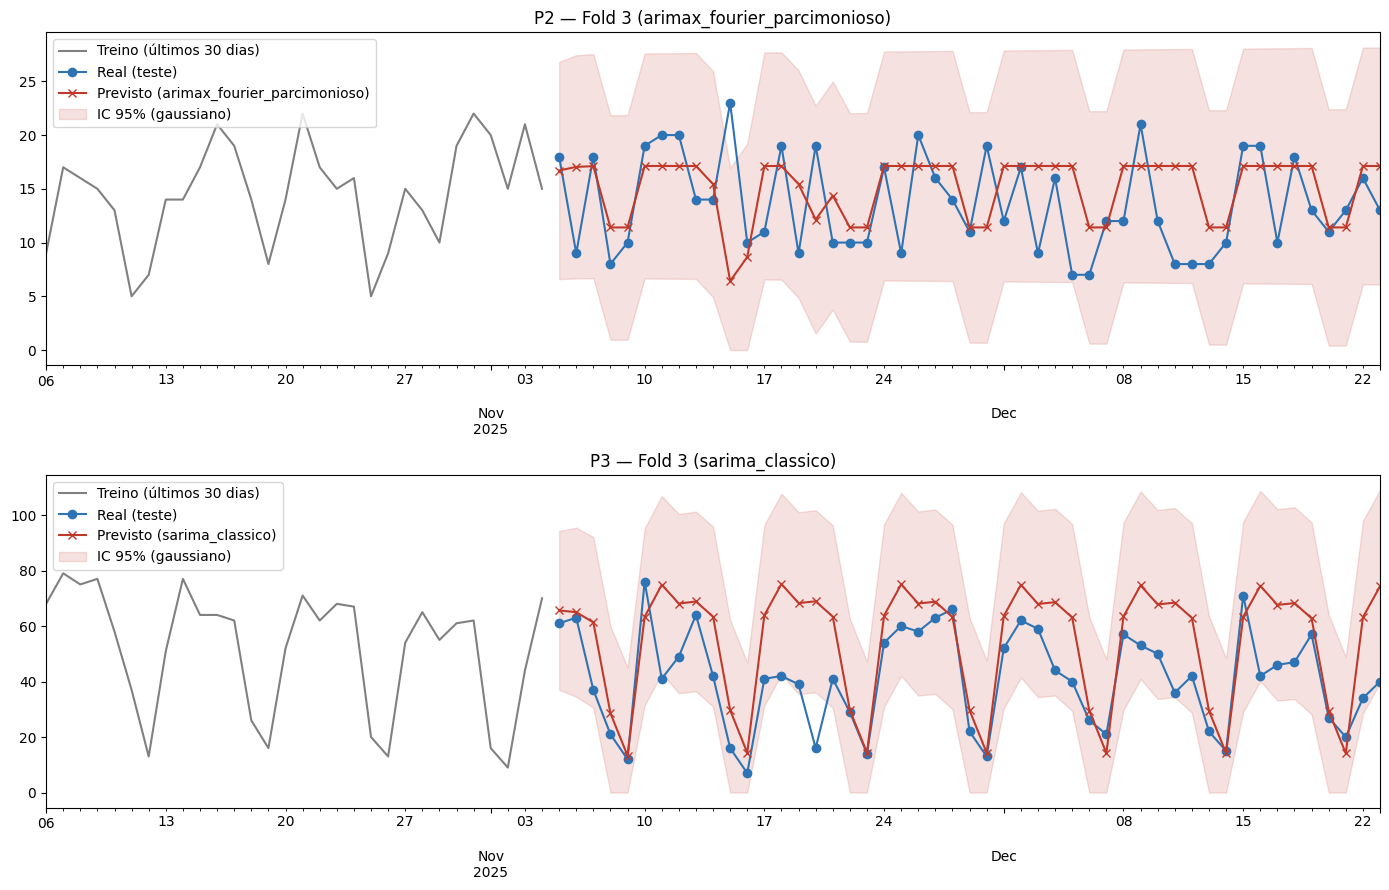

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, nome_serie in zip(axes, SERIES):
    serie = SERIES[nome_serie]
    f3 = folds[-1]
    treino_mask_f3 = (serie.index >= f3['train_start']) & (serie.index <= f3['train_end'])
    teste_mask_f3 = (serie.index >= f3['test_start']) & (serie.index <= f3['test_end'])
    serie_treino_f3, serie_teste_f3 = serie[treino_mask_f3], serie[teste_mask_f3]

    spec_final = especificacao_final_por_serie[nome_serie]
    info_f3 = resultados_por_serie[nome_serie]['modelos_por_fold'][3].get(spec_final)
    if info_f3 is None:
        info_f3 = rodar_variante_sarimax(spec_final, SPECS_SARIMAX_PADRAO[spec_final], serie_treino_f3, serie_teste_f3, exogenas[treino_mask_f3], exogenas[teste_mask_f3])

    serie_treino_f3.iloc[-30:].plot(ax=ax, label='Treino (últimos 30 dias)', color='grey')
    serie_teste_f3.plot(ax=ax, label='Real (teste)', color='#2E74B5', marker='o')
    ax.plot(serie_teste_f3.index, info_f3['previsao'], label=f'Previsto ({spec_final})', color='#c0392b', marker='x')
    ax.fill_between(serie_teste_f3.index, info_f3['ic'][:, 0], info_f3['ic'][:, 1], color='#c0392b', alpha=0.15, label='IC 95% (gaussiano)')
    ax.legend()
    ax.set_title(f'{nome_serie} — Fold 3 ({spec_final})')

plt.tight_layout()
plt.show()


---
## PARTE 8 — Modelo de produção — P2, P3, e a soma Bottom-Up

In [17]:
modelos_producao = {}
previsoes_producao = {}

for nome_serie, serie in SERIES.items():
    spec_final = SPECS_SARIMAX_PADRAO[especificacao_final_por_serie[nome_serie]]
    X_producao = exogenas[spec_final['X_cols']] if spec_final['X_cols'] else None
    usar_log = usar_log_por_serie[nome_serie]
    serie_para_treino = np.log1p(serie) if usar_log else serie

    modelo_producao = pm.auto_arima(
        serie_para_treino, X=X_producao, d=1, seasonal=spec_final['seasonal'], m=7 if spec_final['seasonal'] else 1,
        max_p=3, max_q=3, information_criterion='bic', stepwise=True, suppress_warnings=True, error_action='ignore',
    )
    assert modelo_producao.order[1] == 1
    modelos_producao[nome_serie] = {'modelo': modelo_producao, 'usar_log': usar_log, 'spec': spec_final}
    logger.info('%s: modelo de produção = %s%sx%s | escala=%s', nome_serie, especificacao_final_por_serie[nome_serie], modelo_producao.order, modelo_producao.seasonal_order, 'log1p' if usar_log else 'bruta')


2026-08-30 16:59:46 | INFO     | sarimax_bottomup | P2: modelo de produção = arimax_fourier_parcimonioso(1, 1, 1)x(0, 0, 0, 0) | escala=bruta


INFO:sarimax_bottomup:P2: modelo de produção = arimax_fourier_parcimonioso(1, 1, 1)x(0, 0, 0, 0) | escala=bruta


2026-08-30 17:01:56 | INFO     | sarimax_bottomup | P3: modelo de produção = sarima_classico(0, 1, 2)x(1, 0, 1, 7) | escala=bruta


INFO:sarimax_bottomup:P3: modelo de produção = sarima_classico(0, 1, 2)x(1, 0, 1, 7) | escala=bruta


In [18]:
datas_futuras = pd.date_range(serie_p2.index.max() + pd.Timedelta(days=1), periods=7, freq='D')

for nome_serie in SERIES:
    info = modelos_producao[nome_serie]
    exog_futuro = construir_exogenas_futuras(datas_futuras[0].strftime('%Y-%m-%d'), 7, colunas=info['spec']['X_cols'])
    previsao, ic = info['modelo'].predict(n_periods=7, X=exog_futuro, return_conf_int=True)
    previsao = np.asarray(previsao)

    if info['usar_log']:
        residuos_treino = np.asarray(info['modelo'].arima_res_.resid)
        previsao_final = log1p_bias_corrected_forecast(previsao, residuos_treino)
        ic_final = np.expm1(ic)
    else:
        previsao_final = previsao
        ic_final = ic

    previsao_final = np.maximum(previsao_final, 0)
    ic_final[:, 0] = np.maximum(ic_final[:, 0], 0)

    previsoes_producao[nome_serie] = pd.DataFrame({
        'data': datas_futuras,
        f'previsao_{nome_serie.lower()}': np.round(previsao_final).astype(int),
        f'ic_inferior_{nome_serie.lower()}': np.round(ic_final[:, 0]).astype(int),
        f'ic_superior_{nome_serie.lower()}': np.round(ic_final[:, 1]).astype(int),
    })

df_previsao_total = previsoes_producao['P2'].merge(previsoes_producao['P3'], on='data')
df_previsao_total['previsao_total_p2_p3'] = df_previsao_total['previsao_p2'] + df_previsao_total['previsao_p3']
df_previsao_total['ic_inferior_total'] = df_previsao_total['ic_inferior_p2'] + df_previsao_total['ic_inferior_p3']
df_previsao_total['ic_superior_total'] = df_previsao_total['ic_superior_p2'] + df_previsao_total['ic_superior_p3']

df_previsao_total


,data,previsao_p2,ic_inferior_p2,ic_superior_p2,previsao_p3,ic_inferior_p3,ic_superior_p3,previsao_total_p2_p3,ic_inferior_total,ic_superior_total
0,2026-01-01,10,0,20,14,0,43,24,0,63
1,2026-01-02,11,1,21,18,0,49,29,1,70
2,2026-01-03,9,0,19,0,0,24,9,0,43
3,2026-01-04,9,0,19,0,0,15,9,0,34
4,2026-01-05,14,4,24,19,0,52,33,4,76
5,2026-01-06,14,4,24,20,0,53,34,4,77
6,2026-01-07,14,4,24,16,0,49,30,4,73


**Nota sobre o intervalo de confiança da soma:** somar os limites inferior/superior dos dois ICs (em vez de recalcular a incerteza combinada) é uma aproximação conservadora — assume que os erros de P2 e P3 são perfeitamente correlacionados positivamente, o que tende a produzir um intervalo mais largo do que a incerteza real combinada (se os erros forem parcialmente independentes, o intervalo verdadeiro seria mais estreito). Preferimos errar para um IC mais largo do que subestimar a incerteza da soma.

### 8.1 Coeficientes e diagnóstico formal de resíduos, por prioridade

In [19]:
diagnosticos_producao = {}

for nome_serie in SERIES:
    print(f'========== {nome_serie} ==========')
    print(modelos_producao[nome_serie]['modelo'].summary())
    print()

    diagnostico = diagnostico_residuos(modelos_producao[nome_serie]['modelo'])
    diagnosticos_producao[nome_serie] = diagnostico
    for chave, valor in diagnostico.items():
        logger.info('%s | %s: %s', nome_serie, chave, valor)

    if diagnostico['breusch_pagan_p'] < 0.05:
        logger.warning('%s: Breusch-Pagan confirma heterocedasticidade (p=%.4f) — usar o IC por bootstrap abaixo como referência.', nome_serie, diagnostico['breusch_pagan_p'])
    print()


========== P2 ==========
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  365
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1111.460
Date:                Sun, 30 Aug 2026   AIC                           2236.920
Time:                        17:01:58   BIC                           2264.200
Sample:                    01-01-2025   HQIC                          2247.762
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
fim_de_semana           -5.2598      0.628     -8.371      0.000      -6.491      -4.028
feriado                 -2.6799      1.501     -1.785      0.074      -5.622

INFO:sarimax_bottomup:P2 | ljung_box_p: 0.8189


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P2 | jarque_bera_stat: 205.26


INFO:sarimax_bottomup:P2 | jarque_bera_stat: 205.26


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P2 | jarque_bera_p: 0.0


...

2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P3 | breusch_pagan_stat: 12.03


INFO:sarimax_bottomup:P3 | breusch_pagan_stat: 12.03


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P3 | breusch_pagan_p: 0.0005


INFO:sarimax_bottomup:P3 | breusch_pagan_p: 0.0005


2026-08-30 17:01:58 | WARNING  | sarimax_bottomup | P3: Breusch-Pagan confirma heterocedasticidade (p=0.0005) — usar o IC por bootstrap abaixo como referência.


### 8.2 Intervalo de previsão por bootstrap dos resíduos, por prioridade

In [20]:
for nome_serie in SERIES:
    info = modelos_producao[nome_serie]
    residuos = np.asarray(info['modelo'].arima_res_.resid)
    previsao_pontual = previsoes_producao[nome_serie][f'previsao_{nome_serie.lower()}'].values

    ic_bootstrap = bootstrap_prediction_interval(residuos, previsao_pontual if not info['usar_log'] else np.log1p(previsao_pontual))
    if info['usar_log']:
        ic_bootstrap = {
            'ic_inferior': log1p_bias_corrected_forecast(ic_bootstrap['ic_inferior'], residuos),
            'ic_superior': log1p_bias_corrected_forecast(ic_bootstrap['ic_superior'], residuos),
        }

    previsoes_producao[nome_serie][f'ic_inferior_bootstrap_{nome_serie.lower()}'] = np.round(np.maximum(ic_bootstrap['ic_inferior'], 0)).astype(int)
    previsoes_producao[nome_serie][f'ic_superior_bootstrap_{nome_serie.lower()}'] = np.round(ic_bootstrap['ic_superior']).astype(int)

    logger.info('%s: IC bootstrap calculado.', nome_serie)

df_previsao_total['ic_inferior_bootstrap_total'] = previsoes_producao['P2'][f'ic_inferior_bootstrap_p2'].values + previsoes_producao['P3'][f'ic_inferior_bootstrap_p3'].values
df_previsao_total['ic_superior_bootstrap_total'] = previsoes_producao['P2'][f'ic_superior_bootstrap_p2'].values + previsoes_producao['P3'][f'ic_superior_bootstrap_p3'].values

df_previsao_total[['data', 'previsao_p2', 'previsao_p3', 'previsao_total_p2_p3', 'ic_inferior_bootstrap_total', 'ic_superior_bootstrap_total']]


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P2: IC bootstrap calculado.


INFO:sarimax_bottomup:P2: IC bootstrap calculado.


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P3: IC bootstrap calculado.


INFO:sarimax_bottomup:P3: IC bootstrap calculado.


,data,previsao_p2,previsao_p3,previsao_total_p2_p3,ic_inferior_bootstrap_total,ic_superior_bootstrap_total
0,2026-01-01,10,14,24,1,65
1,2026-01-02,11,18,29,3,72
2,2026-01-03,9,0,9,1,53
3,2026-01-04,9,0,9,1,51
4,2026-01-05,14,19,33,5,74
5,2026-01-06,14,20,34,6,76
6,2026-01-07,14,16,30,6,73


### 8.3 Visão consolidada — P2 + P3

A análise técnica é sempre separada (P2 e P3 têm dinâmicas diferentes, tratadas como tal do início ao fim) — mas a decisão de negócio ("quantos chamados a operação deve esperar amanhã e na próxima semana") é sobre o total. Esta seção existe só para apresentar isso de forma direta, sem reabrir nenhuma decisão de modelagem.

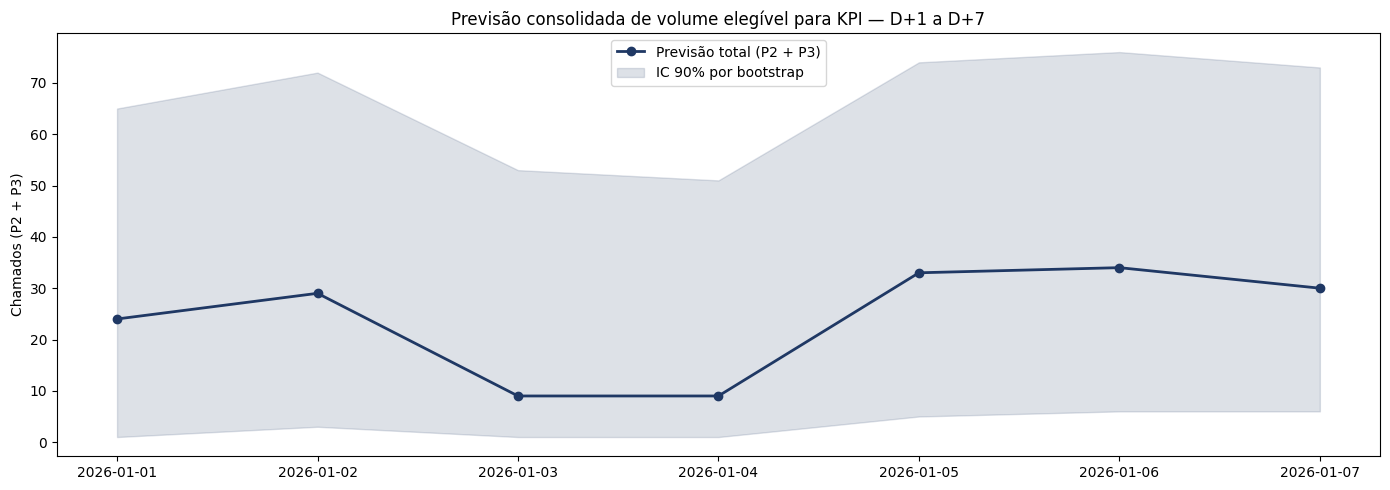

2026-08-30 17:01:58 | INFO     | sarimax_bottomup | W+1 consolidado (P2+P3): 168 chamados [23, 464] (IC 90% bootstrap)


INFO:sarimax_bottomup:W+1 consolidado (P2+P3): 168 chamados [23, 464] (IC 90% bootstrap)


,métrica,valor
0,Previsão D+1 (total),24
1,Previsão W+1 (soma dos 7 dias),168
2,IC inferior W+1,23
3,IC superior W+1,464


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_previsao_total['data'], df_previsao_total['previsao_total_p2_p3'], marker='o', color='#1F3864', linewidth=2, label='Previsão total (P2 + P3)')
ax.fill_between(
    df_previsao_total['data'], df_previsao_total['ic_inferior_bootstrap_total'], df_previsao_total['ic_superior_bootstrap_total'],
    color='#1F3864', alpha=0.15, label='IC 90% por bootstrap',
)
ax.set_title('Previsão consolidada de volume elegível para KPI — D+1 a D+7')
ax.set_ylabel('Chamados (P2 + P3)')
ax.legend()
plt.tight_layout()
plt.show()

w1_total = int(df_previsao_total['previsao_total_p2_p3'].sum())
w1_ic_inferior = int(df_previsao_total['ic_inferior_bootstrap_total'].sum())
w1_ic_superior = int(df_previsao_total['ic_superior_bootstrap_total'].sum())

logger.info('W+1 consolidado (P2+P3): %d chamados [%d, %d] (IC 90%% bootstrap)', w1_total, w1_ic_inferior, w1_ic_superior)

resumo_consolidado = pd.DataFrame({
    'métrica': ['Previsão D+1 (total)', 'Previsão W+1 (soma dos 7 dias)', 'IC inferior W+1', 'IC superior W+1'],
    'valor': [
        int(df_previsao_total['previsao_total_p2_p3'].iloc[0]),
        w1_total, w1_ic_inferior, w1_ic_superior,
    ],
})
resumo_consolidado


---
## PARTE 9 — Teto Contratual — comparação com as metas oficiais (Dicionário de Dados v2)

Dois comparativos, propositalmente separados:
1. **Atingimento real de 2025** — o volume elegível que já fechou no ano, direto da série histórica (sem projeção nenhuma).
2. **Projeção 2026** — extrapolação simples do ritmo do D+7 (soma semanal × 52) contra a mesma meta. É uma extrapolação ingênua, não uma previsão do ano inteiro — dito isso explicitamente, para não passar mais confiança do que ela tem.

In [22]:
print('=== 1. Atingimento REAL de 2025 (sem projeção) ===')
volume_real_2025_p2 = int(serie_p2.sum())
volume_real_2025_p3 = int(serie_p3.sum())
pct_real_p2 = checar_faixa_kpi(volume_real_2025_p2, FAIXAS_VOLUME_ANUAL_P2)
pct_real_p3 = checar_faixa_kpi(volume_real_2025_p3, FAIXAS_VOLUME_ANUAL_P3)
logger.info('P2 2025: volume elegível = %d -> %s%% de atingimento da meta anual', volume_real_2025_p2, pct_real_p2)
logger.info('P3 2025: volume elegível = %d -> %s%% de atingimento da meta anual', volume_real_2025_p3, pct_real_p3)

print()
print('=== 2. Projeção 2026 (extrapolação ingênua do ritmo do D+7) ===')
projecao_anual_p2 = int(df_previsao_total['previsao_p2'].sum() * 52)
projecao_anual_p3 = int(df_previsao_total['previsao_p3'].sum() * 52)
pct_projetado_p2 = checar_faixa_kpi(projecao_anual_p2, FAIXAS_VOLUME_ANUAL_P2)
pct_projetado_p3 = checar_faixa_kpi(projecao_anual_p3, FAIXAS_VOLUME_ANUAL_P3)
logger.info('P2: se o ritmo da semana prevista se mantivesse o ano todo -> %d/ano -> %s%% de atingimento', projecao_anual_p2, pct_projetado_p2)
logger.info('P3: se o ritmo da semana prevista se mantivesse o ano todo -> %d/ano -> %s%% de atingimento', projecao_anual_p3, pct_projetado_p3)

resumo_teto_contratual = pd.DataFrame({
    'prioridade': ['P2', 'P3'],
    'volume_real_2025': [volume_real_2025_p2, volume_real_2025_p3],
    'pct_atingimento_2025': [pct_real_p2, pct_real_p3],
    'projecao_anualizada_2026': [projecao_anual_p2, projecao_anual_p3],
    'pct_atingimento_projetado_2026': [pct_projetado_p2, pct_projetado_p3],
})
resumo_teto_contratual


=== 1. Atingimento REAL de 2025 (sem projeção) ===
2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P2 2025: volume elegível = 5159 -> 125% de atingimento da meta anual


INFO:sarimax_bottomup:P2 2025: volume elegível = 5159 -> 125% de atingimento da meta anual


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P3 2025: volume elegível = 19997 -> 125% de atingimento da meta anual


INFO:sarimax_bottomup:P3 2025: volume elegível = 19997 -> 125% de atingimento da meta anual



=== 2. Projeção 2026 (extrapolação ingênua do ritmo do D+7) ===
2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P2: se o ritmo da semana prevista se mantivesse o ano todo -> 4212/ano -> 150% de atingimento


INFO:sarimax_bottomup:P2: se o ritmo da semana prevista se mantivesse o ano todo -> 4212/ano -> 150% de atingimento


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | P3: se o ritmo da semana prevista se mantivesse o ano todo -> 4524/ano -> 150% de atingimento


INFO:sarimax_bottomup:P3: se o ritmo da semana prevista se mantivesse o ano todo -> 4524/ano -> 150% de atingimento


,prioridade,volume_real_2025,pct_atingimento_2025,projecao_anualizada_2026,pct_atingimento_projetado_2026
0,P2,5159,125,4212,150
1,P3,19997,125,4524,150


**Como ler:** a projeção 2026 é sensível ao dia da semana em que ela é calculada (7 dias específicos, não uma média do ano) — não é uma previsão de atingimento anual robusta, é uma leitura rápida de "estamos no mesmo patamar do ano passado, ou o ritmo mudou?". Para uma projeção anual de verdade, seria preciso rodar o modelo em cascata ao longo do ano (re-treinar a cada novo trecho de dado real) — fora do escopo desta entrega, mas registrado aqui como próximo passo natural.

---
## PARTE 10 — Checagens de sanidade

In [23]:
assert all(modelos_producao[s]['modelo'].order[1] == 1 for s in SERIES), 'd=1 não respeitado em algum modelo de produção!'
assert df_previsao_total.shape[0] == 7
assert (df_previsao_total['previsao_total_p2_p3'] == df_previsao_total['previsao_p2'] + df_previsao_total['previsao_p3']).all(), 'a soma bottom-up não bate!'
assert (df_previsao_total['ic_inferior_bootstrap_total'] <= df_previsao_total['previsao_total_p2_p3']).all()
assert (df_previsao_total['ic_superior_bootstrap_total'] >= df_previsao_total['previsao_total_p2_p3']).all()
assert (df_previsao_total['previsao_p2'] >= 0).all() and (df_previsao_total['previsao_p3'] >= 0).all(), 'previsão negativa detectada!'
assert (df_previsao_total['ic_inferior_bootstrap_total'] >= 0).all(), 'IC inferior negativo detectado!'
assert resumo_teto_contratual['pct_atingimento_2025'].notna().all(), 'algum volume real de 2025 caiu fora de todas as faixas oficiais!'
logger.info('Checagens de sanidade: OK.')


2026-08-30 17:01:58 | INFO     | sarimax_bottomup | Checagens de sanidade: OK.


INFO:sarimax_bottomup:Checagens de sanidade: OK.


---
## PARTE 11 — Persistência dos modelos de produção

In [24]:
for nome_serie in SERIES:
    caminho_modelo = salvar_artefato(modelos_producao[nome_serie]['modelo'], PROJECT_PATHS.gold / 'modelos' / f'sarimax_producao_{nome_serie.lower()}.joblib')
    logger.info('Modelo SARIMAX de produção (%s) salvo em: %s', nome_serie, caminho_modelo)


2026-08-30 17:01:59 | INFO     | sarimax_bottomup | Modelo SARIMAX de produção (P2) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p2.joblib


INFO:sarimax_bottomup:Modelo SARIMAX de produção (P2) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p2.joblib


2026-08-30 17:01:59 | INFO     | sarimax_bottomup | Modelo SARIMAX de produção (P3) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p3.joblib


INFO:sarimax_bottomup:Modelo SARIMAX de produção (P3) salvo em: /content/drive/MyDrive/cronos_project/data/gold/modelos/sarimax_producao_p3.joblib


---
## PARTE 12 — Resumo de execução

In [25]:
resumo_execucao = f'''
EXECUÇÃO DO MODELO SARIMAX BOTTOM-UP (Desafio 1, v4) — {pd.Timestamp.now(tz="UTC").isoformat()}

Modo de dados: {MODO_DADOS.upper()} (decisão de negócio — ver justificativa na Seção 0.1.1)

Abordagem: Bottom-Up — P2 e P3 modelados separadamente, somados na produção.
Baseline de árvore (CatBoost) removido desta versão por decisão de negócio — o projeto já
compara contra 4 baselines clássicos (naive, sazonal, média móvel, ARIMA puro) por série.

Especificação final por série:
{chr(10).join(f"  {s}: {especificacao_final_por_serie[s]} | escala={'log1p' if usar_log_por_serie[s] else 'bruta'}" for s in SERIES)}

Previsão D+1 a D+7 (bottom-up, a partir de {serie_p2.index.max().date()}) — sem valores negativos:
{df_previsao_total[['data','previsao_p2','previsao_p3','previsao_total_p2_p3']].to_string(index=False)}

Visão consolidada:
{resumo_consolidado.to_string(index=False)}

Teto Contratual (Dicionário de Dados v2):
{resumo_teto_contratual.to_string(index=False)}

Diagnóstico de resíduos:
{chr(10).join(f"  {s}: {diagnosticos_producao[s]}" for s in SERIES)}
'''.strip()

print(resumo_execucao)


EXECUÇÃO DO MODELO SARIMAX BOTTOM-UP (Desafio 1, v4) — 2026-08-30T17:01:59.998790+00:00

Modo de dados: ELEGÍVEL PARA KPI (decisão de negócio — ver justificativa na Seção 0.1.1)

Abordagem: Bottom-Up — P2 e P3 modelados separadamente, somados na produção.
Baseline de árvore (CatBoost) removido desta versão por decisão de negócio — o projeto já
compara contra 4 baselines clássicos (naive, sazonal, média móvel, ARIMA puro) por série.

Especificação final por série:
  P2: arimax_fourier_parcimonioso | escala=bruta
  P3: sarima_classico | escala=bruta

Previsão D+1 a D+7 (bottom-up, a partir de 2025-12-31) — sem valores negativos:
      data  previsao_p2  previsao_p3  previsao_total_p2_p3
2026-01-01           10           14                    24
2026-01-02           11           18                    29
2026-01-03            9            0                     9
2026-01-04            9            0                     9
2026-01-05           14           19                    33
2026-01-06 